In [ ]:
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEndpoint ,ChatHuggingFace
from typing import TypedDict, Annotated
import operator
from langgraph.graph import StateGraph, START, END

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

True

In [ ]:
model_id = "meta-llama/Llama-3.1-8B-Instruct"

llm = HuggingFaceEndpoint(
    repo_id=model_id,
    task="text-generation",
    max_new_tokens=256,
    huggingfacehub_api_token=hf_token,
    temperature=0.7,
    do_sample=True,
    repetition_penalty=1.1,
)

model = ChatHuggingFace(llm=llm)

d:\Learner\Recap\Lang Graph\01_Foundation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
class BlogPlan(TypedDict):
    topic: str
    title: str
    plans: Annotated[list[str], operator.add]

In [17]:
def get_a_plan(state: BlogPlan) -> BlogPlan:
    prompt = f"Suggest me plan for resarch and write a blog on given topic: {state['topic']}"

    plan = model.invoke(prompt)

    return {
        "plans": [plan.content]
    }

def assosiate_stats(state: BlogPlan) -> BlogPlan:
    return state

In [18]:
graph = StateGraph(BlogPlan)

graph.add_node('plan_1', get_a_plan)
graph.add_node('plan_2', get_a_plan)
graph.add_node('assosiate_stats', assosiate_stats)

graph.add_edge(START, 'plan_1')
graph.add_edge(START, 'plan_2')

graph.add_edge('plan_1', 'assosiate_stats')
graph.add_edge('plan_2', 'assosiate_stats')


graph.add_edge('assosiate_stats', END)

workflow = graph.compile()

In [19]:
result = workflow.invoke({
    'topic': 'Maharana Pratap'
})

print(result)

{'topic': 'Maharana Pratap', 'plans': ['**Research Plan and Blog on Maharana Pratap**\n\n**Topic:** Maharana Pratap: A Symbol of Courage and Patriotism\n\n**Objective:**\n\n*   To research and write a comprehensive blog on Maharana Pratap, a legendary figure in Indian history.\n*   To highlight his life, achievements, and struggles, and to inspire readers with his courage and patriotism.\n\n**Research Methodology:**\n\n1.  **Literature Review:** Study existing books, articles, and online resources on Maharana Pratap to gather information about his life, reign, and struggles.\n2.  **Primary Sources:** Consult primary sources such as the official website of the Mewar Kingdom, historical documents, and personal accounts of people who knew him.\n3.  **Interviews:** Conduct interviews with historians, scholars, and people who have written about Maharana Pratap to gain a deeper understanding of his life and reign.\n4.  **Field Research:** Visit the birthplace and other important locations as

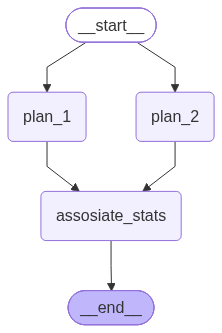

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())